In [1]:
%load_ext autoreload
%autoreload 2
import random
import pandas as pd 
from scipy.special import softmax 
import h5py
import pyBigWig
import numpy as np 
from kerasAC.helpers.transform_bpnet_io import * 
## for plotting 
import matplotlib 
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"]=10,10
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 10}

matplotlib.rc('font', **font)

## load the model labels & predictions 

In [2]:
#load the predictions from bpnet,tobias,and 6mer bias models 
preds=h5py.File("k562.dnase.with.bpnet.bias.0.predictions",'r')


In [3]:
coords=preds['coords'][:]
coords=[tuple([i.decode('utf8')  for i in j[0:2]]) for j in coords]
coord_to_index={}  
for i in range(len(coords)): 
    cur_chrom=coords[i][0] 
    cur_pos=int(coords[i][1])
    coord_to_index[tuple([cur_chrom,cur_pos])]=i


In [4]:
index0=coords.index(('chr1','16013361'))
index1=coords.index(('chr1','18531116'))
index2=coords.index(('chr1','34852845'))
index3=coords.index(('chr1','52552769'))
index4=coords.index(('chr1','66446571'))
coords_to_plot=[index0,index1,index2,index3,index4]

In [5]:
toplot=get_model_outputs_to_plot(preds,coords_to_plot)


In [6]:
toplot.keys()

dict_keys(['labels_counts', 'labels_logits', 'labels_prob', 'predictions_counts', 'predictions_logits', 'predictions_prob', 'delta_logits', 'delta_prob', 'labels_sum', 'predictions_sum'])

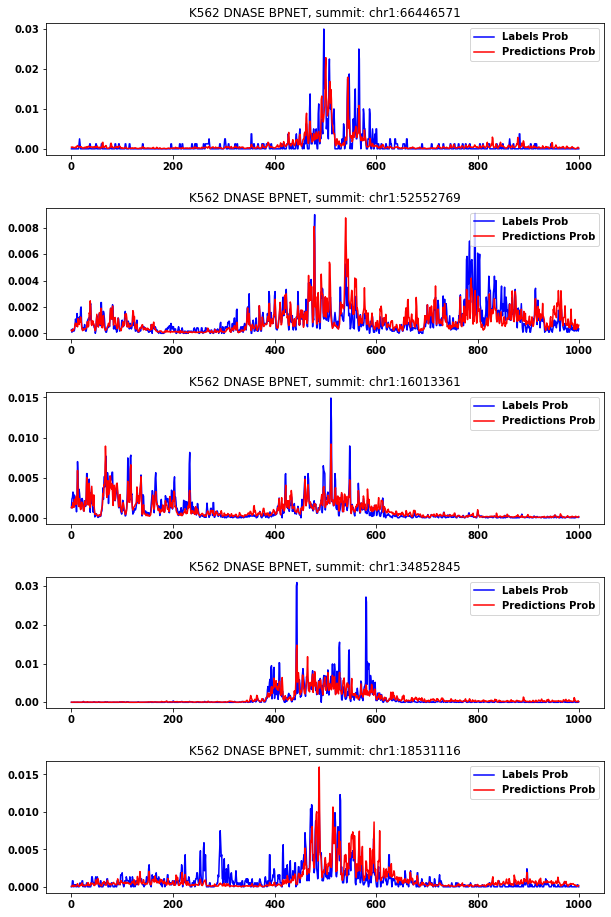

In [10]:
plt.rcParams["figure.figsize"]=10,16
fig, axes = plt.subplots(5, 1)
#labels 
axes[0].plot(toplot['labels_prob'][4],label='Labels Prob',color='b',)
axes[0].plot(toplot['predictions_prob'][4],label='Predictions Prob',color='r')
axes[0].set_title('K562 DNASE BPNET, summit: chr1:66446571')
axes[0].legend(loc=1)

axes[1].plot(toplot['labels_prob'][3],label='Labels Prob',color='b')
axes[1].plot(toplot['predictions_prob'][3],label='Predictions Prob',color='r')
axes[1].set_title('K562 DNASE BPNET, summit: chr1:52552769')
axes[1].legend(loc=1)


axes[2].plot(toplot['labels_prob'][0],label='Labels Prob',color='b')
axes[2].plot(toplot['predictions_prob'][0],label='Predictions Prob',color='r')
axes[2].set_title('K562 DNASE BPNET, summit: chr1:16013361')
axes[2].legend(loc=1)


axes[3].plot(toplot['labels_prob'][2],label='Labels Prob',color='b')
axes[3].plot(toplot['predictions_prob'][2],label='Predictions Prob',color='r')
axes[3].set_title('K562 DNASE BPNET, summit: chr1:34852845')
axes[3].legend(loc=1)


axes[4].plot(toplot['labels_prob'][1],label='Labels Prob',color='b')
axes[4].plot(toplot['predictions_prob'][1],label='Predictions Prob',color='r')
axes[4].set_title('K562 DNASE BPNET, summit: chr1:18531116')
axes[4].legend(loc=1)

plt.subplots_adjust(hspace=0.4)


In [8]:
toplot

{'labels_counts': array([[22., 41., 44., ...,  2.,  2.,  1.],
        [ 0.,  0.,  3., ...,  1.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  1.],
        [ 3.,  1.,  4., ...,  4.,  2.,  4.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]]),
 'labels_logits': array([[-6.5971908 , -6.00817708, -5.94017086, ..., -8.44578461,
         -8.44578461, -8.7566967 ],
        [-9.21024037, -9.21024037, -7.00888697, ..., -7.90796804,
         -9.21024037, -9.21024037],
        [-9.21024037, -9.21024037, -9.21024037, ..., -9.21024037,
         -9.21024037, -8.46808297],
        [-7.9577035 , -8.60432415, -7.74408271, ..., -7.74408271,
         -8.229661  , -7.74408271],
        [-9.21024037, -9.21024037, -9.21024037, ..., -9.21024037,
         -9.21024037, -9.21024037]]),
 'labels_prob': array([[1.26233647e-03, 2.35253615e-03, 2.52467294e-03, ...,
         1.14757861e-04, 1.14757861e-04, 5.73789305e-05],
        [0.00000000e+00, 0.00000000e+00, 8.02997859e-04, ...,
         2.67665953e-04, 0.000

## 1D Gaussian smoothing 

In [45]:
from scipy.spatial.distance import jensenshannon
from scipy.signal import fftconvolve 
from scipy.signal import  gaussian 

0.41081336820586783

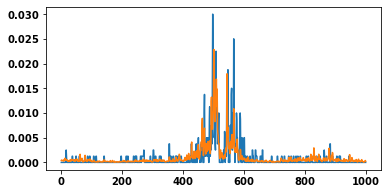

In [47]:
#unsmoothed signal 
lab_prob=toplot['labels_prob'][4]
pred_prob=toplot['predictions_prob'][4]
plt.plot(lab_prob)
plt.plot(pred_prob)
jensenshannon(lab_prob,pred_prob)

In [48]:
#make gaussian kernel 
gauss_kernel=gaussian(7,3)
gauss_kernel

array([0.60653066, 0.8007374 , 0.94595947, 1.        , 0.94595947,
       0.8007374 , 0.60653066])

In [49]:
#convolve gaussian w/ signal 
lab_prob_smooth=fftconvolve(lab_prob,gauss_kernel,mode='same')
pred_prob_smooth=fftconvolve(pred_prob,gauss_kernel,mode='same')

In [55]:
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

lab_prob_smooth=smooth(lab_prob,7)
pred_prob_smooth=smooth(pred_prob,7)

0.2591358139280971

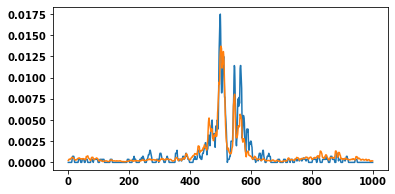

In [56]:
plt.plot(lab_prob_smooth)
plt.plot(pred_prob_smooth)
#get some negative values, which make jsd behave badly 
lab_prob_smooth[lab_prob_smooth<0]=0
jensenshannon(lab_prob_smooth,pred_prob_smooth)

In [57]:
jensenshannon(lab_prob_smooth,pred_prob)

0.2898488922419595

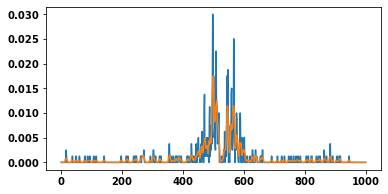

In [58]:
#compare smoothed vs original -- they are not on the same scale though ?
plt.plot(lab_prob)
plt.plot(lab_prob_smooth)

## MNLL 

In [11]:
import numpy as np
import scipy

#amtseng's implementation: 
def multinomial_log_probs(category_log_probs, trials, query_counts):
    """                                                                                                                                                                  
    Defines multinomial distributions and computes the probability of seeing                                                                                             
    the queried counts under these distributions. This defines D different                                                                                               
    distributions (that all have the same number of classes), and returns D                                                                                              
    probabilities corresponding to each distribution.                                                                                                                    
    Arguments:                                                                                                                                                           
        `category_log_probs`: a D x N array containing log probabilities (base                                                                                           
            e) of seeing each of the N classes/categories                                                                                                                
        `trials`: a D-array containing the total number of trials for each                                                                                               
            distribution (can be different numbers)                                                                                                                      
        `query_counts`: a D x N array containing the observed count of each                                                                                              
            category in each distribution; the probability is computed for these                                                                                         
            observations                                                                                                                                                 
    Returns a D-array containing the log probabilities (base e) of each observed                                                                                         
    query with its corresponding distribution. Note that D can be replaced with                                                                                          
    any shape (i.e. only the last dimension is reduced).                                                                                                                 
    """
    # Multinomial probability = n! / (x1!...xk!) * p1^x1 * ... pk^xk                                                                                                     
    # Log prob = log(n!) - (log(x1!) ... + log(xk!)) + x1log(p1) ... + xklog(pk)                                                                                         
    log_n_fact = scipy.special.gammaln(trials + 1)
    log_counts_fact = scipy.special.gammaln(query_counts + 1)
    log_counts_fact_sum = np.sum(log_counts_fact, axis=-1)
    log_prob_pows = category_log_probs * query_counts  # Elementwise                                                                                                     
    log_prob_pows_sum = np.sum(log_prob_pows, axis=-1)
    return log_n_fact - log_counts_fact_sum + log_prob_pows_sum


In [12]:
toplot['labels_counts'].shape

(5, 1000)

In [13]:
toplot['predictions_prob'].shape

(5, 1000)

In [14]:
toplot['labels_sum'].shape

(5,)

In [15]:
mnnll_alex=multinomial_log_probs(np.log(toplot['predictions_prob']),
                                   np.exp(toplot['labels_sum']),
                                   toplot['labels_counts'])

In [16]:
mnnll_alex

array([-4038.88772288, -2707.60107625, -4018.66729566, -3867.44504106,
        -853.4682491 ])